In [1]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anujms/car-damage-detection")

print("Path to dataset files:", path)

In [2]:

!kaggle datasets download anujms/car-damage-detection

Dataset URL: https://www.kaggle.com/datasets/anujms/car-damage-detection
License(s): unknown
100% 123M/123M [00:03<00:00, 35.5MB/s]



In [3]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/car-damage-detection.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [4]:
!ls

car-damage-detection.zip  data1a  kaggle.json  sample_data


In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split


In [9]:
train_path = "/content/data1a/training"

total_train_images = 0
for category in os.listdir(train_path):
    category_path = os.path.join(train_path, category)
    total_train_images += len(os.listdir(category_path))

print("Total training images:", total_train_images)

Total training images: 1840


In [10]:
val_path = "/content/data1a/validation"

total_val_images = 0
for category in os.listdir(val_path):
    category_path = os.path.join(val_path, category)
    total_val_images += len(os.listdir(category_path))

print("Total validation images:", total_val_images)

Total validation images: 460


In [12]:
label_map = {
    "00-damage": 0,
    "01-whole": 1
}

In [17]:
import os
import cv2

data = []
labels = []

train_path = "/content/data1a/training"

for category in os.listdir(train_path):
    path = os.path.join(train_path, category)
    label = label_map[category]

    for img in os.listdir(path):
        img_path = os.path.join(path, img)

        image = cv2.imread(img_path)
        image = cv2.resize(image, (128, 128))

        data.append(image)
        labels.append(label)

print("Total images:", len(data))
print("Total labels:", len(labels))

Total images: 1840
Total labels: 1840


In [19]:
X=np.array(data)
Y=np.array(labels)

In [20]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, random_state=2)

In [21]:
print(X.shape, X_train.shape, X_test.shape)

(1840, 128, 128, 3) (1472, 128, 128, 3) (368, 128, 128, 3)


In [22]:
X_train_scaled=X_train/255
X_test_scaled=X_test/255

In [23]:
import tensorflow as tf
from tensorflow import keras


In [57]:
num_of_classs=2

model=keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))




model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(128, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.3))

model.add(keras.layers.Dense(64, activation='relu'))



model.add(keras.layers.Dense(32, activation='relu'))



model.add(keras.layers.Dense(num_of_classs, activation='softmax'))

In [59]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])

In [60]:
history=model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=30)

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - acc: 0.5937 - loss: 0.6592 - val_acc: 0.7095 - val_loss: 0.5599
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.7069 - loss: 0.5739 - val_acc: 0.7230 - val_loss: 0.5244
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.7432 - loss: 0.5196 - val_acc: 0.7635 - val_loss: 0.4864
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.7719 - loss: 0.4666 - val_acc: 0.7432 - val_loss: 0.4912
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.8172 - loss: 0.4073 - val_acc: 0.7838 - val_loss: 0.4656
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.8406 - loss: 0.3674 - val_acc: 0.7432 - val_loss: 0.5483
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.8618 - loss: 0.3025 - val_acc: 0.7297 - val_loss: 0.6276
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.8973 - loss: 0.2249 - val_acc: 0.7635 - val_loss: 0.7138
Epoch 9/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9131

In [61]:
loss, accuracy=model.evaluate(X_test_scaled, Y_test)
print("Test Accuracy:", accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - acc: 0.7636 - loss: 1.6981
Test Accuracy: 0.7635869383811951


path of the image to be predict/content/data1a/validation/00-damage/0001.JPEG


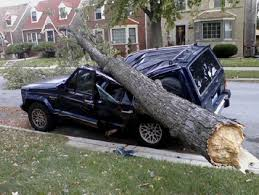

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[0.98963565 0.01036439]]
Predicted Label: 0
The Damage is Visible


In [65]:
input_image_path=input("path of the image to be predict")

input_image=cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized=cv2.resize(input_image, (128,128))

input_image_scaled=input_image_resized/255

input_image_reshaped=np.reshape(input_image_scaled, [1,128,128,3])

input_prediction=model.predict(input_image_reshaped)

print(input_prediction)

input_pred_label=np.argmax(input_prediction)

print("Predicted Label:", input_pred_label)

if input_pred_label==0:
  print("The Damage is Visible")
else:
  print("The Damage is not Visible")